In [8]:
from google.colab import drive
drive.mount('/content/drive')
# Now you can access your file at:
# '/content/drive/My Drive/Mining_process_database_Practica/MiningProcess_Flotation_Plant_Database.csv'

Mounted at /content/drive


In [9]:
ruta = '/content/drive/My Drive/Mining_process_database_Practica/MiningProcess_Flotation_Plant_Database.csv'
df_completo = pd.read_csv(ruta, decimal=",")
df = df_completo.sample(n=100000, random_state=42).reset_index(drop=True)
print(f"Tamaño del nuevo dataset: {df.shape[0]} filas y {df.shape[1]} columnas.\n")
df.head()

Tamaño del nuevo dataset: 100000 filas y 24 columnas.



,date,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
0,2017-05-08 07:00:00,56.65,14.83,2969.800000,474.569,397.08500,9.62077,1.71086,249.935,250.636,...,306.320,465.618000,444.682,444.627,346.892,342.489,346.306,332.807,63.53,3.54
1,2017-03-14 09:00:00,60.24,8.87,3751.370000,552.399,405.80600,9.22732,1.76000,250.697,255.399,...,249.005,809.941503,451.085,459.480,435.234,443.874,428.583,446.508,65.68,1.30
2,2017-03-14 12:00:00,60.24,8.87,3770.700000,518.311,401.49900,9.26991,1.75000,250.455,251.752,...,249.796,462.852000,444.826,450.737,450.390,470.805,465.606,475.089,65.61,2.08
3,2017-08-12 21:00:00,48.81,25.31,3633.310000,335.078,378.75031,10.10850,1.67378,299.487,254.001,...,248.950,561.548000,535.820,541.708,532.424,551.883,560.056,547.340,67.19,1.45
4,2017-03-11 09:00:00,59.89,8.98,794.536195,561.523,400.66400,9.39431,1.76000,248.236,249.983,...,249.565,559.146000,363.291,557.063,517.736,514.869,555.328,535.318,65.15,2.97


In [41]:
print("=== INFORMACIÓN GENERAL ===")
df.info()
print("\n=== VALORES NULOS POR COLUMNA ===")
print(df.isnull().sum())
print("\n=== CANTIDAD DE FILAS DUPLICADAS ===")
print(f"Total de duplicados: {df.duplicated().sum()}")


=== INFORMACIÓN GENERAL ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   date                          100000 non-null  datetime64[ns]
 1   % Iron Feed                   100000 non-null  float64       
 2   % Silica Feed                 100000 non-null  float64       
 3   Starch Flow                   100000 non-null  float64       
 4   Amina Flow                    100000 non-null  float64       
 5   Ore Pulp Flow                 100000 non-null  float64       
 6   Ore Pulp pH                   100000 non-null  float64       
 7   Ore Pulp Density              100000 non-null  float64       
 8   Flotation Column 01 Air Flow  100000 non-null  float64       
 9   Flotation Column 02 Air Flow  100000 non-null  float64       
 10  Flotation Column 03 Air Flow  100000 non-null  float6

In [40]:
#Se establece la columnas de fecha y se crean las de turno y calidad de la silica para aumentar la diversidad de datos
col_silica = '% Silica Concentrate'
df['Calidad_Silica'] = df[col_silica].apply(lambda x: 'Alta Pureza' if x < 3.0 else 'Baja Pureza')
print("Nuevas columnas creadas con éxito:")
df[['date', 'Turno', 'Calidad_Silica']].head()

Nuevas columnas creadas con éxito:


,date,Turno,Calidad_Silica
0,2017-05-08 07:00:00,Turno Noche,Baja Pureza
1,2017-03-14 09:00:00,Turno Día,Alta Pureza
2,2017-03-14 12:00:00,Turno Día,Alta Pureza
3,2017-08-12 21:00:00,Turno Noche,Alta Pureza
4,2017-03-11 09:00:00,Turno Día,Alta Pureza


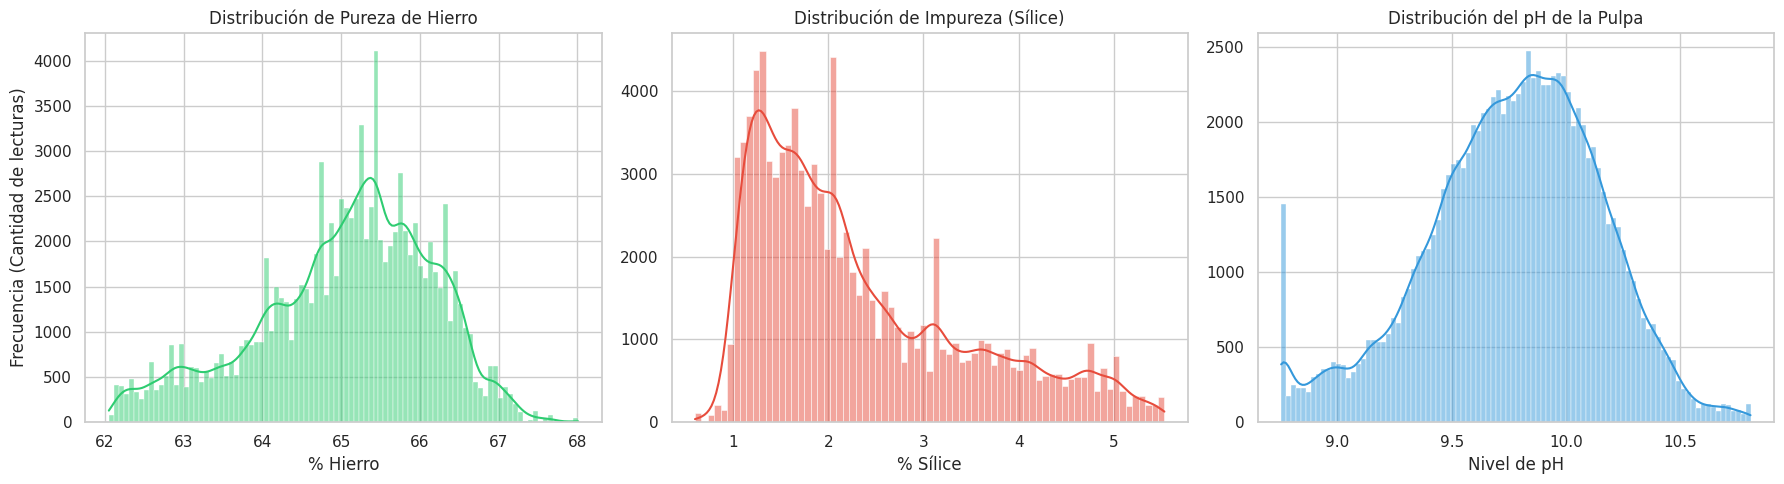

In [31]:
# Herramientas de dibujo
import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set_theme(style="whitegrid")

# Canva
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO 1: Pureza del Hierro ---
# ax=axes[0] significa que va en el primer lugar de la izquierda
sns.histplot(data=df, x='% Iron Concentrate', kde=True, color='#2ecc71', ax=axes[0])
axes[0].set_title('Distribución de Pureza de Hierro')
axes[0].set_xlabel('% Hierro')
axes[0].set_ylabel('Frecuencia (Cantidad de lecturas)')

# --- GRÁFICO 2: Impureza (Sílice) ---
# ax=axes[1] va en el medio
sns.histplot(data=df, x='% Silica Concentrate', kde=True, color='#e74c3c', ax=axes[1])
axes[1].set_title('Distribución de Impureza (Sílice)')
axes[1].set_xlabel('% Sílice')
axes[1].set_ylabel('') # Borramos el texto del eje Y para no repetir

# --- GRÁFICO 3: pH de la Pulpa ---
# ax=axes[2] va a la derecha
sns.histplot(data=df, x='Ore Pulp pH', kde=True, color='#3498db', ax=axes[2])
axes[2].set_title('Distribución del pH de la Pulpa')
axes[2].set_xlabel('Nivel de pH')
axes[2].set_ylabel('')

# Ajustamos los márgenes para que no se superpongan y mostramos el resultado
plt.tight_layout()
plt.show()

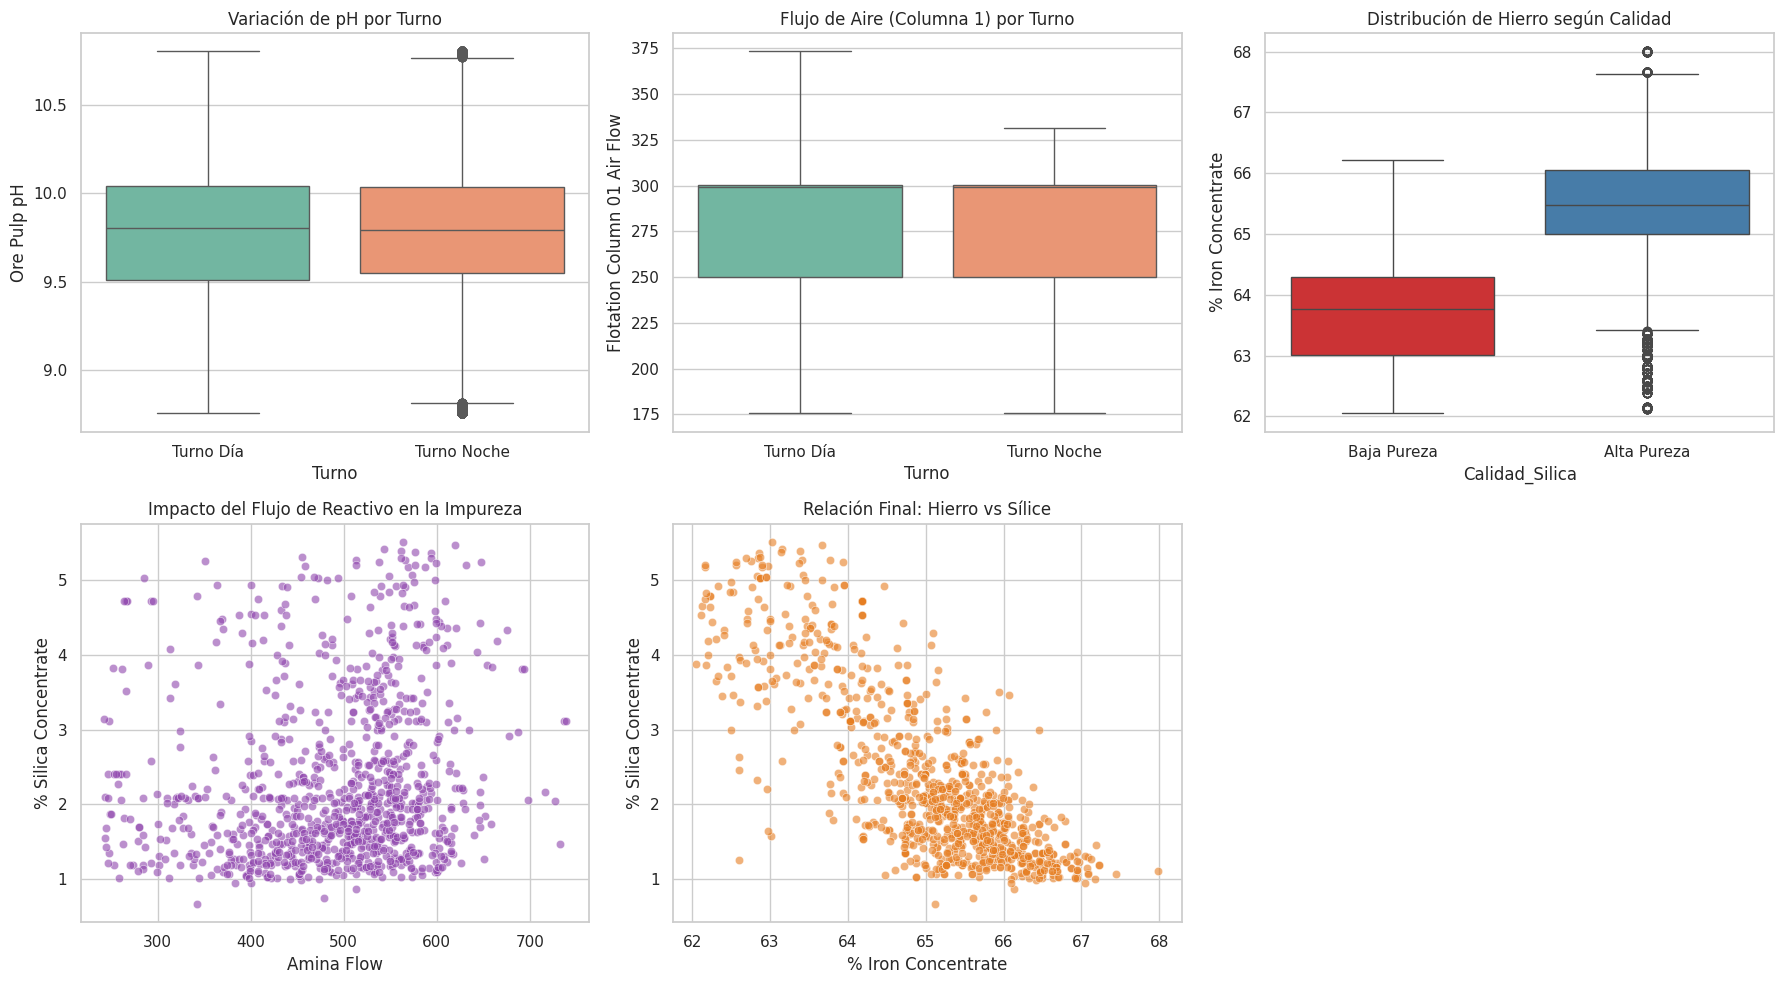

In [36]:
# --- Horarios, boxplots y scatterplots ---
def asignar_turno_real(hora):
    if 7 <= hora < 19:
        return 'Turno Día'
    else:
        return 'Turno Noche'

# Aplicamos la función para sobreescribir la memoria de Colab
df['Turno'] = df['date'].dt.hour.apply(asignar_turno_real)

# --- 2. DIBUJAMOS LOS GRÁFICOS ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
orden_turnos = ['Turno Día', 'Turno Noche']

# 1. pH de la pulpa vs Turno
sns.boxplot(data=df, x='Turno', y='Ore Pulp pH', ax=axes[0,0], order=orden_turnos, hue='Turno', palette='Set2')
axes[0,0].set_title('Variación de pH por Turno')

# 2. Flujo de Aire vs Turno
sns.boxplot(data=df, x='Turno', y='Flotation Column 01 Air Flow', ax=axes[0,1], order=orden_turnos, hue='Turno', palette='Set2')
axes[0,1].set_title('Flujo de Aire (Columna 1) por Turno')

# 3. Pureza de Hierro vs Categoría de Calidad
sns.boxplot(data=df, x='Calidad_Silica', y='% Iron Concentrate', ax=axes[0,2], hue='Calidad_Silica', palette='Set1')
axes[0,2].set_title('Distribución de Hierro según Calidad')

# --- SCATTERPLOTS ---
df_sample = df.sample(1000, random_state=42)

# 4. Reactivo (Amina) vs Impureza (Sílice)
sns.scatterplot(data=df_sample, x='Amina Flow', y='% Silica Concentrate', alpha=0.6, color='#8e44ad', ax=axes[1,0])
axes[1,0].set_title('Impacto del Flujo de Reactivo en la Impureza')

# 5. Concentrado de Hierro vs Concentrado de Sílice
sns.scatterplot(data=df_sample, x='% Iron Concentrate', y='% Silica Concentrate', alpha=0.6, color='#e67e22', ax=axes[1,1])
axes[1,1].set_title('Relación Final: Hierro vs Sílice')

fig.delaxes(axes[1,2])
plt.tight_layout()
plt.show()

/tmp/ipykernel_2271/1550961946.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Turno', order=['Turno Día', 'Turno Noche'], palette='viridis', ax=axes[1])
/tmp/ipykernel_2271/1550961946.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Turno', y='% Iron Concentrate', order=['Turno Día', 'Turno Noche'],


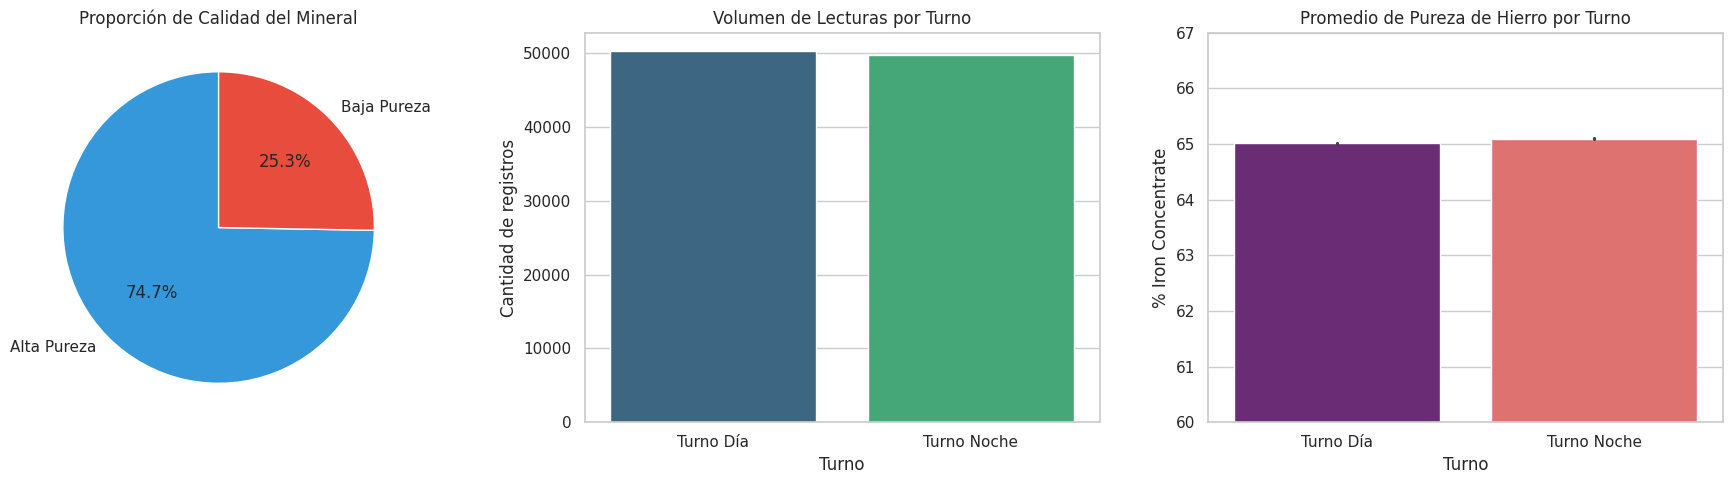

In [37]:
# --- 3. DIBUJAMOS LOS GRÁFICOS DE BARRAS Y TORTA ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Torta: Proporción de Calidad
calidad_counts = df['Calidad_Silica'].value_counts()
axes[0].pie(calidad_counts, labels=calidad_counts.index, autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[0].set_title('Proporción de Calidad del Mineral')

# 2. Barras: Cantidad de lecturas
sns.countplot(data=df, x='Turno', order=['Turno Día', 'Turno Noche'], palette='viridis', ax=axes[1])
axes[1].set_title('Volumen de Lecturas por Turno')
axes[1].set_ylabel('Cantidad de registros')

# 3. Barras: Promedio de pureza
sns.barplot(data=df, x='Turno', y='% Iron Concentrate', order=['Turno Día', 'Turno Noche'],
            palette='magma', ax=axes[2])
axes[2].set_title('Promedio de Pureza de Hierro por Turno')
axes[2].set_ylim(60, 67)

plt.tight_layout()
plt.show()